  SqO — Shot Quality & Optimization  |  NBA 2023-24 Season

[1/4] Fetching shot data from NBA Stats API...
  Loading Stephen Curry... 1445 shots loaded ✓
  Loading Giannis Antetokounmpo... 1369 shots loaded ✓
  Loading DeMar DeRozan... 1355 shots loaded ✓
  Loading Kevin Durant... 1436 shots loaded ✓
  Loading Nikola Jokic... 1411 shots loaded ✓

  Total shots loaded: 7,016

[2/4] Building KDE shot quality surfaces...
  Stephen Curry: PPS range 0.580–1.936 ✓
  Giannis Antetokounmpo: PPS range 0.541–1.731 ✓
  DeMar DeRozan: PPS range 0.592–1.767 ✓
  Kevin Durant: PPS range 0.623–2.237 ✓
  Nikola Jokic: PPS range 0.599–1.721 ✓

[3/4] Computing zone-level Expected Value audit...

  SHOT QUALITY AUDIT — Expected Points Per Shot by Zone
  Player                       Archetype               Rim  Corner3     Mid   AbvBrk3
  -------------------------------------------------------------------------
  Stephen Curry                Elite Shooter         1.244    1.571   0.830     1.183
  Giannis 

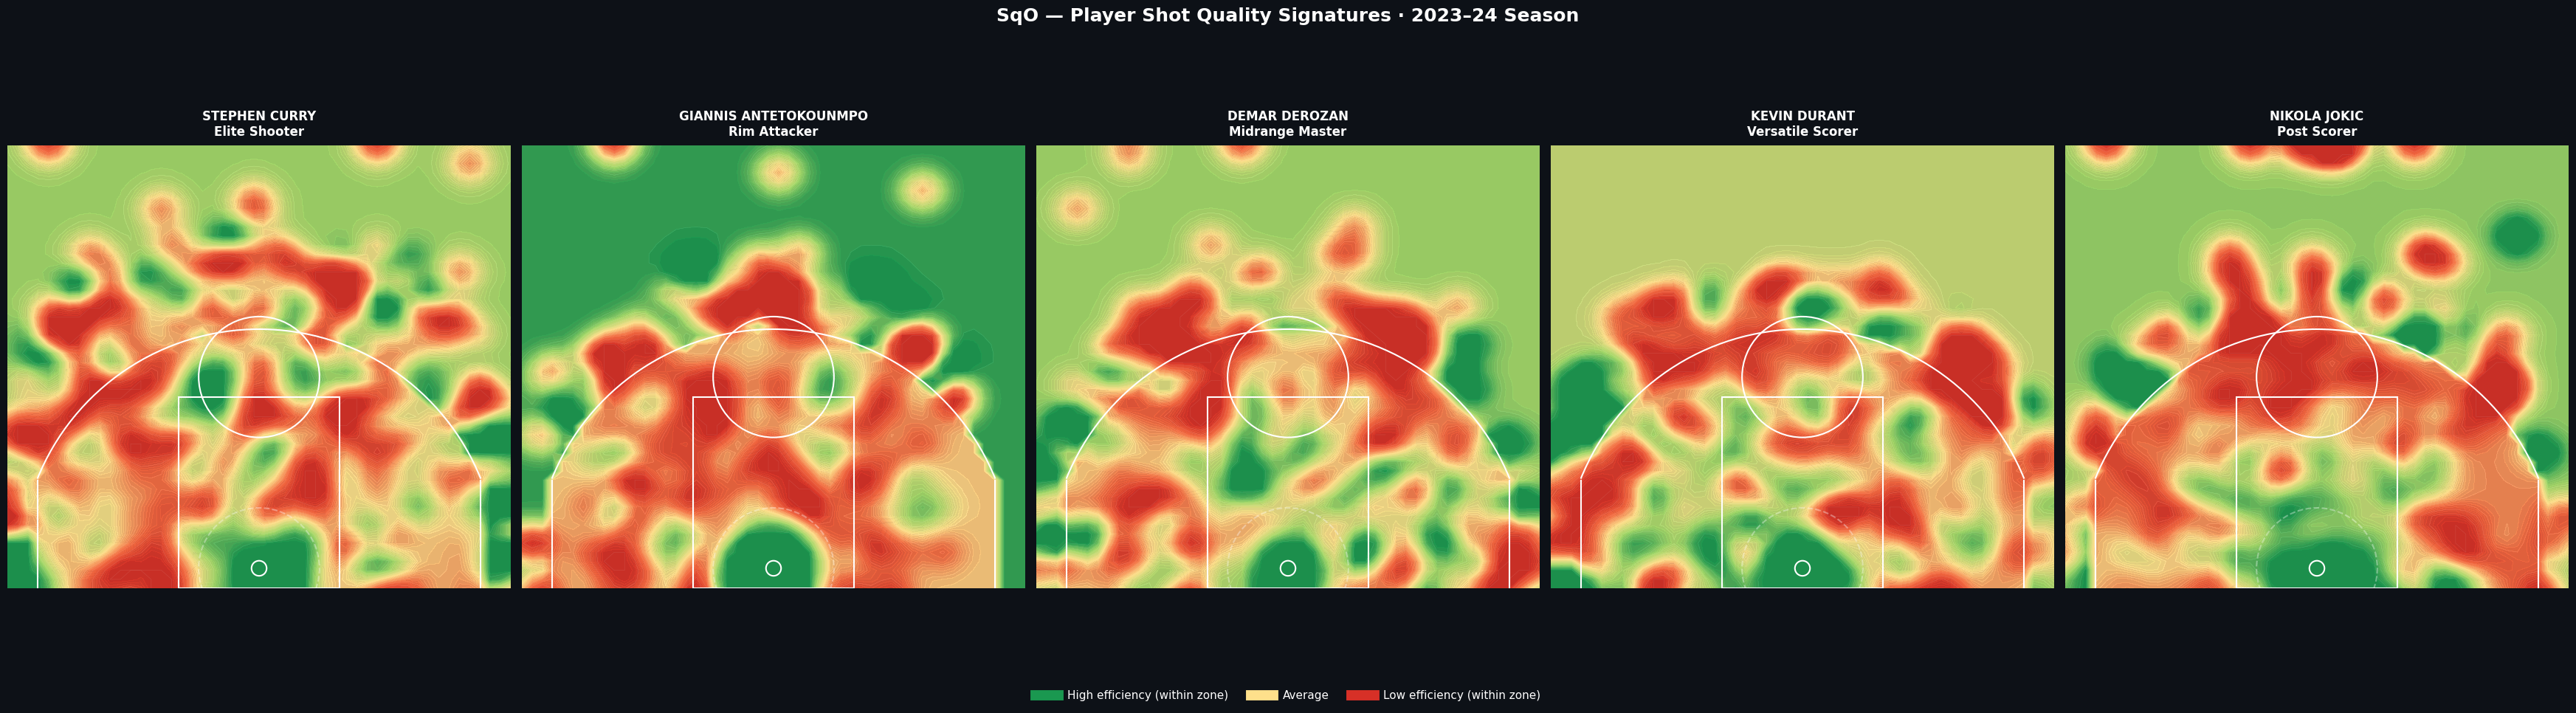

  Saved: sqo_signatures.png ✓


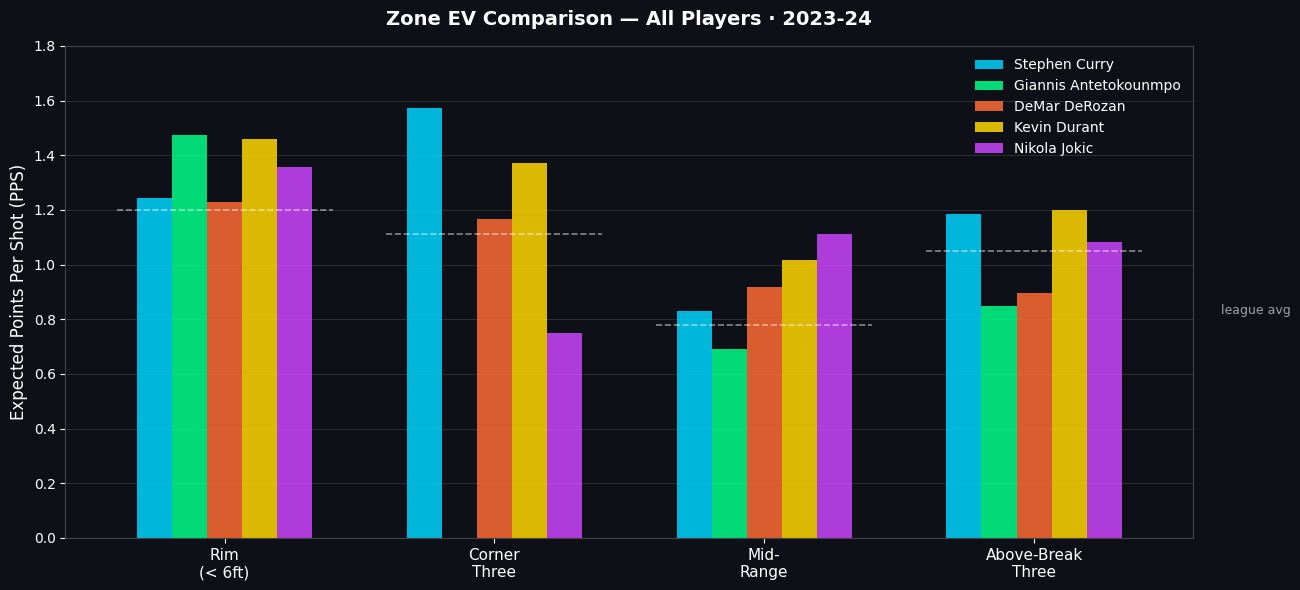

  Saved: sqo_ev_comparison.png ✓


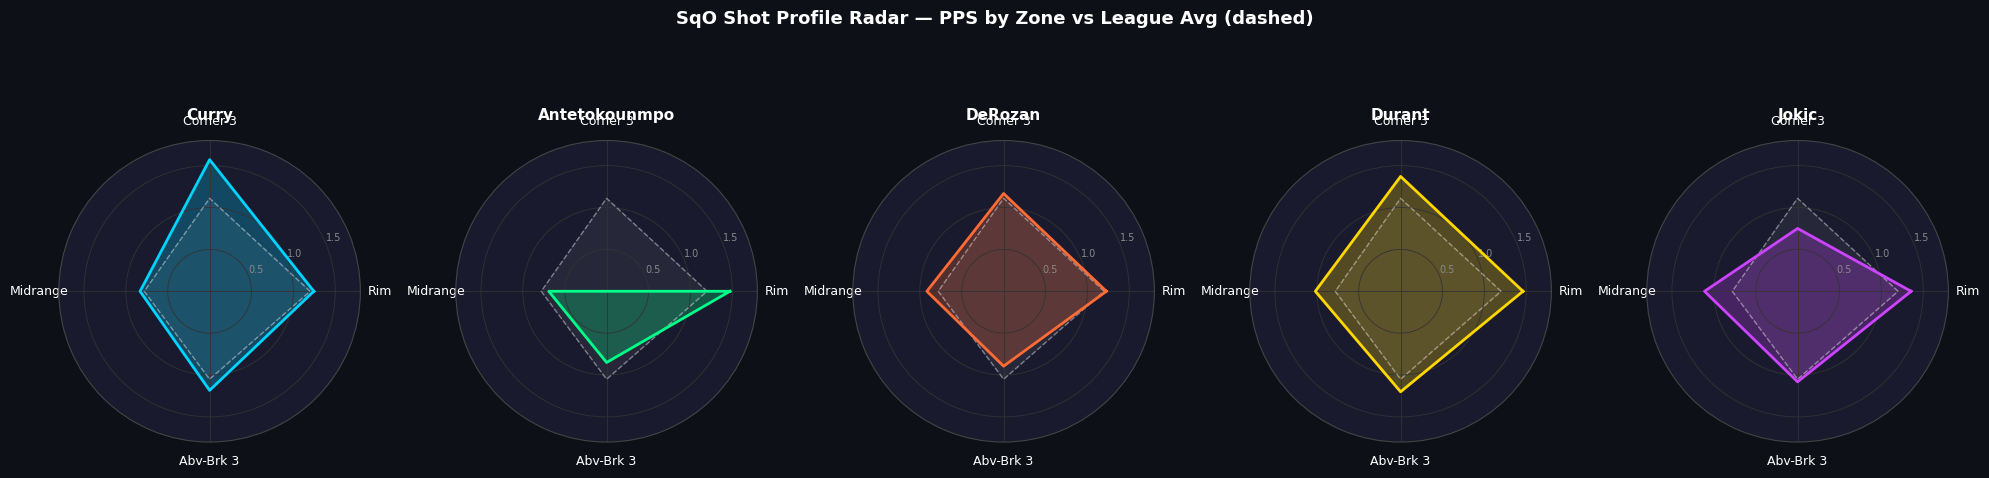

  Saved: sqo_radar.png ✓

  SqO DEFENSIVE SCOUTING REPORT
  How to guard each player based on their shot signature

  [STEPHEN CURRY — Elite Shooter]
  Force to:   Rim / Long Midrange
  Avoid:      Above-Break Three / Corner Three
  Key stat:   Corner 3 EV = 1.571 (41% above league avg)
  Scheme:     Hard close-out on all catch-and-shoot situations. Ice ball-screen coverage — push him baseline, not middle. Never go under screens.

  [GIANNIS ANTETOKOUNMPO — Rim Attacker]
  Force to:   Corner Three
  Avoid:      Rim / Elbow
  Key stat:   Corner 3 EV = 0.000 | Rim EV = 1.472
  Scheme:     Drop coverage on ball screens — pack the paint. Shade him toward corners on drive-and-kick. Wall up at the rim; do not help off corner shooters.

  [DEMAR DEROZAN — Midrange Master]
  Force to:   Three-Point Line
  Avoid:      Midrange / Elbow
  Key stat:   Mid EV = 0.916 (17% above league avg — rare efficiency)
  Scheme:     Deny elbow catches. Force him off the three-point line into step-back range — 

In [7]:
# ============================================================
# NBA Shot Quality & Optimization (SqO)
# Author: Atiksh Singh | University of Connecticut
# Data:   NBA Stats API (nba_api) · 2023-24 Season
# Method: Gaussian KDE · Bayesian Prior · PPS Surface
# ============================================================

!pip install nba_api scipy matplotlib numpy pandas seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Arc, Circle, Rectangle
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter
from nba_api.stats.endpoints import shotchartdetail, playercareerstats
import time, warnings
warnings.filterwarnings('ignore')

print("=" * 65)
print("  SqO — Shot Quality & Optimization  |  NBA 2023-24 Season")
print("=" * 65)


# ─── CONFIGURATION ────────────────────────────────────────────────

PLAYERS = [ # Dictionary of players metadata
    {"name": "Stephen Curry",           "id": 201939, "archetype": "Elite Shooter",    "team": "Warriors"},
    {"name": "Giannis Antetokounmpo",   "id": 203507, "archetype": "Rim Attacker",     "team": "Bucks"},
    {"name": "DeMar DeRozan",           "id": 201942, "archetype": "Midrange Master",  "team": "Bulls"},
    {"name": "Kevin Durant",            "id": 201142, "archetype": "Versatile Scorer", "team": "Suns"},
    {"name": "Nikola Jokic",            "id": 203999, "archetype": "Post Scorer",      "team": "Nuggets"},
]

SEASON       = "2023-24"
# Defining the resolution of a half court into a 50x50 grid of squares
GRID_W       = 50
GRID_H       = 50
X_RANGE      = (-25, 25)
Y_RANGE      = (-2,  42)
SIGMA        = 1.5       # KDE bandwidth in feet, spreading the heat further out
PRIOR_SHOTS  = 0.5         # Bayesian prior weight (pseudo-shots at league avg)
LEAGUE_AVG   = 0.46      # League average FG% prior

CMAP = LinearSegmentedColormap.from_list("sqo", [
    "#d73027", "#f46d43", "#fee08b", "#a6d96a", "#1a9850"
])


# ─── 1. DATA INGESTION ────────────────────────────────────────────

def fetch_shots(player_id, player_name, season=SEASON):
    """Pull real shot chart data from NBA Stats API."""
    time.sleep(0.6)
    try:
        response = shotchartdetail.ShotChartDetail(
            team_id=0, player_id=player_id,
            context_measure_simple='FGA',
            season_nullable=season
        )
        df = response.get_data_frames()[0]
        df = df[['LOC_X','LOC_Y','SHOT_MADE_FLAG','SHOT_TYPE',
                 'ACTION_TYPE','SHOT_ZONE_BASIC','SHOT_DISTANCE']].copy()
        df['LOC_X']    = df['LOC_X'] / 10
        df['LOC_Y']    = df['LOC_Y'] / 10
        df['DIST']     = np.sqrt(df['LOC_X']**2 + df['LOC_Y']**2)
        df['IS_THREE'] = ((df['DIST'] >= 23.75) | (df['LOC_X'].abs() >= 22)).astype(int)
        df['PLAYER']   = player_name
        return df
    except Exception as e:
        print(f"    ERROR fetching {player_name}: {e}")
        return None

print("\n[1/4] Fetching shot data from NBA Stats API...")
all_data = {}
for p in PLAYERS:
    print(f"  Loading {p['name']}...", end=" ")
    df = fetch_shots(p['id'], p['name'])
    if df is not None:
        all_data[p['name']] = df
        print(f"{len(df)} shots loaded ✓")

print(f"\n  Total shots loaded: {sum(len(d) for d in all_data.values()):,}")


# ─── 2. KDE SHOT QUALITY MODEL ────────────────────────────────────

def build_pps_surface(df, sigma=SIGMA):
    """
    Gaussian KDE = Bayesian-smoothed FG% → Points Per Shot surface.
    """
    gx  = np.linspace(*X_RANGE, GRID_W)
    gy  = np.linspace(*Y_RANGE, GRID_H)
    GX, GY = np.meshgrid(gx, gy)

    makes_grid    = np.zeros((GRID_H, GRID_W))
    attempts_grid = np.zeros((GRID_H, GRID_W))

    for _, row in df.iterrows():
        xi = int(np.clip((row['LOC_X'] - X_RANGE[0]) / (X_RANGE[1]-X_RANGE[0]) * (GRID_W-1), 0, GRID_W-1))
        yi = int(np.clip((row['LOC_Y'] - Y_RANGE[0]) / (Y_RANGE[1]-Y_RANGE[0]) * (GRID_H-1), 0, GRID_H-1))
        attempts_grid[yi, xi] += 1
        makes_grid[yi, xi]    += row['SHOT_MADE_FLAG']

    sm = gaussian_filter(makes_grid,    sigma=sigma)
    sa = gaussian_filter(attempts_grid, sigma=sigma)

    # Bayesian shrinkage prior: pull sparse zones toward league average
    fg_pct = (sm + PRIOR_SHOTS * LEAGUE_AVG) / (sa + PRIOR_SHOTS)

    DIST_GRID  = np.sqrt(GX**2 + GY**2)
    IS_THREE   = ((DIST_GRID >= 23.75) | (np.abs(GX) >= 22)).astype(float)
    pps        = fg_pct * (2 + IS_THREE)

    return pps, IS_THREE, fg_pct

print("\n[2/4] Building KDE shot quality surfaces...")
surfaces = {}
for name, df in all_data.items():
    pps, is_three, fg = build_pps_surface(df)
    surfaces[name] = {"pps": pps, "is_three": is_three, "fg": fg}
    print(f"  {name}: PPS range {pps.min():.3f}–{pps.max():.3f} ✓")


# ─── 3. ZONE EV AUDIT ─────────────────────────────────────────────

def zone_ev(df):
    """Compute EV and shot volume by strategic zone."""
    zones = {
        'Rim (< 6ft)':        df[df['DIST'] < 6],
        'Corner Three':       df[(df['LOC_X'].abs() >= 22) & (df['LOC_Y'] < 10)],
        'Midrange':           df[(df['DIST'] >= 6) & (df['DIST'] < 23.75) & (df['LOC_X'].abs() < 22)],
        'Above-Break Three':  df[(df['DIST'] >= 23.75) & (df['LOC_X'].abs() < 22)],
    }
    pts = {'Rim (< 6ft)': 2, 'Corner Three': 3, 'Midrange': 2, 'Above-Break Three': 3}
    results = {}
    for zone, sub in zones.items():
        if len(sub) == 0:
            results[zone] = {'ev': 0.0, 'fg_pct': 0.0, 'attempts': 0, 'makes': 0}
        else:
            fg  = sub['SHOT_MADE_FLAG'].mean()
            results[zone] = {
                'ev':       round(fg * pts[zone], 3),
                'fg_pct':   round(fg * 100, 1),
                'attempts': len(sub),
                'makes':    int(sub['SHOT_MADE_FLAG'].sum()),
            }
    return results

LEAGUE_BASELINES = {
    'Rim (< 6ft)':       1.20,
    'Corner Three':      1.11,
    'Midrange':          0.78,
    'Above-Break Three': 1.05,
}

print("\n[3/4] Computing zone-level Expected Value audit...")
audit_rows = []
for p in PLAYERS:
    name = p['name']
    if name not in all_data: continue
    ev   = zone_ev(all_data[name])
    row  = {'Player': name, 'Archetype': p['archetype']}
    for zone, stats in ev.items():
        short = zone.replace('Above-Break Three','AbvBrk3').replace('Rim (< 6ft)','Rim').replace('Corner Three','Corner3').replace('Midrange','Mid')
        row[f'{short}_EV']       = stats['ev']
        row[f'{short}_FG%']      = stats['fg_pct']
        row[f'{short}_Attempts'] = stats['attempts']
    audit_rows.append(row)

audit_df = pd.DataFrame(audit_rows)

# Print clean table
print()
print("=" * 75)
print("  SHOT QUALITY AUDIT — Expected Points Per Shot by Zone")
print("=" * 75)
print(f"  {'Player':<28} {'Archetype':<20} {'Rim':>6} {'Corner3':>8} {'Mid':>7} {'AbvBrk3':>9}")
print("  " + "-" * 73)
for _, r in audit_df.iterrows():
    print(f"  {r['Player']:<28} {r['Archetype']:<20} "
          f"{r['Rim_EV']:>6.3f} {r['Corner3_EV']:>8.3f} "
          f"{r['Mid_EV']:>7.3f} {r['AbvBrk3_EV']:>9.3f}")
print("  " + "-" * 73)
print(f"  {'League Average':<28} {'Baseline':<20} "
      f"{'~1.20':>6} {'~1.11':>8} {'~0.78':>7} {'~1.05':>9}")
print("=" * 75)

# Key insights
print("\n  KEY INSIGHTS:")
for _, r in audit_df.iterrows():
    best_zone = max(['Rim_EV','Corner3_EV','Mid_EV','AbvBrk3_EV'], key=lambda z: r[z])
    worst_zone = min(['Rim_EV','Corner3_EV','Mid_EV','AbvBrk3_EV'], key=lambda z: r[z])
    baseline_map = {'Rim_EV': 1.20, 'Corner3_EV': 1.11, 'Mid_EV': 0.78, 'AbvBrk3_EV': 1.05}
    best_vs_avg = ((r[best_zone] - baseline_map[best_zone]) / baseline_map[best_zone]) * 100
    print(f"  → {r['Player']}: Best zone is {best_zone.replace('_EV','')} "
          f"({r[best_zone]:.3f} PPS, {best_vs_avg:+.0f}% vs league avg)")


# ─── 4. VISUALIZATION — HEATMAPS ──────────────────────────────────

def draw_court(ax, color='white', lw=1.5):
    ax.add_patch(Circle((0, 0), 0.75,  linewidth=lw, color=color, fill=False))
    ax.add_patch(Circle((0, 0), 6,     linewidth=lw, color=color, fill=False,
                         linestyle='--', alpha=0.35))
    ax.add_patch(Arc((0, 0), 47.5, 47.5, theta1=22, theta2=158, linewidth=lw, color=color))
    ax.plot([-22, -22], [Y_RANGE[0], 8.75], color=color, lw=lw)
    ax.plot([ 22,  22], [Y_RANGE[0], 8.75], color=color, lw=lw)
    ax.add_patch(Rectangle((-8, Y_RANGE[0]), 16, 19, linewidth=lw, color=color, fill=False))
    ax.add_patch(Circle((0, 19), 6, linewidth=lw, color=color, fill=False))

def normalize_within_zones(surface, is_three):
    """Scale color independently inside/outside arc to reveal within-zone gradients."""
    result = np.zeros_like(surface)
    for mask in [is_three.astype(bool), ~is_three.astype(bool)]:
        vals = surface[mask]
        lo, hi = np.percentile(vals, 5), np.percentile(vals, 95)
        result[mask] = np.clip((surface[mask] - lo) / (hi - lo + 1e-9), 0, 1)
    return result

gx = np.linspace(*X_RANGE, GRID_W)
gy = np.linspace(*Y_RANGE, GRID_H)

print("\n[4/4] Generating visualizations...")

# --- FIGURE 1: Player Signature Heatmaps ---
n = len(surfaces)
fig, axes = plt.subplots(1, n, figsize=(7*n, 9), facecolor='#0d1117')
plt.suptitle("SqO — Player Shot Quality Signatures · 2023–24 Season",
             color='white', fontsize=18, y=1.02, fontweight='bold')

for i, p in enumerate(PLAYERS):
    name = p['name']
    if name not in surfaces: continue
    ax = axes[i]
    ax.set_facecolor('#0d1117')
    surf = surfaces[name]
    normed = normalize_within_zones(surf['pps'], surf['is_three'])
    im = ax.contourf(gx, gy, normed, levels=50, cmap=CMAP, vmin=0, vmax=1, alpha=0.93)
    ax.contour(gx, gy, normed, levels=12, colors='white', alpha=0.12, linewidths=0.4)
    draw_court(ax)
    ax.set_xlim(*X_RANGE)
    ax.set_ylim(*Y_RANGE)
    ax.set_aspect('equal')
    ax.set_axis_off()
    ax.set_title(f"{name.upper()}\n{p['archetype']}",
                 color='white', fontsize=12, pad=10, fontweight='bold')

legend_elements = [
    Line2D([0],[0], color='#1a9850', lw=10, label='High efficiency (within zone)'),
    Line2D([0],[0], color='#fee08b', lw=10, label='Average'),
    Line2D([0],[0], color='#d73027', lw=10, label='Low efficiency (within zone)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, frameon=False,
           fontsize=11, labelcolor='white', bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('sqo_signatures.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("  Saved: sqo_signatures.png ✓")


# --- FIGURE 2: EV Bar Chart Comparison ---
fig, ax = plt.subplots(figsize=(13, 6), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

zones_short = ['Rim_EV', 'Corner3_EV', 'Mid_EV', 'AbvBrk3_EV']
zone_labels  = ['Rim\n(< 6ft)', 'Corner\nThree', 'Mid-\nRange', 'Above-Break\nThree']
colors_p     = ['#00d4ff', '#00ff88', '#ff6b35', '#ffd700', '#cc44ff']
n_zones      = len(zones_short)
n_players    = len(audit_df)
width        = 0.13
x            = np.arange(n_zones)

for i, (_, row) in enumerate(audit_df.iterrows()):
    vals    = [row[z] for z in zones_short]
    offset  = (i - n_players / 2 + 0.5) * width
    bars    = ax.bar(x + offset, vals, width, label=row['Player'],
                     color=colors_p[i], alpha=0.85, edgecolor='none')

# League average line
for j, (zone, baseline) in enumerate(LEAGUE_BASELINES.items()):
    ax.hlines(baseline, x[j] - 0.4, x[j] + 0.4,
              colors='white', linestyles='--', linewidth=1.2, alpha=0.5)

ax.text(n_zones - 0.05, 0.82, 'league avg', color='white', fontsize=9,
        alpha=0.6, ha='right')

ax.set_xticks(x)
ax.set_xticklabels(zone_labels, color='white', fontsize=11)
ax.set_ylabel('Expected Points Per Shot (PPS)', color='white', fontsize=12)
ax.set_title('Zone EV Comparison — All Players · 2023-24',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.tick_params(colors='white')
ax.spines[['top','right','left','bottom']].set_color('#444444')
ax.set_ylim(0, 1.8)
ax.yaxis.grid(True, color='#333333', linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(frameon=False, labelcolor='white', fontsize=10,
          loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig('sqo_ev_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("  Saved: sqo_ev_comparison.png ✓")


# --- FIGURE 3: Shot Distribution Radar (Shot Profile) ---
from matplotlib.patches import FancyArrowPatch

fig, axes = plt.subplots(1, len(audit_df), figsize=(4*len(audit_df), 5),
                          facecolor='#0d1117', subplot_kw=dict(polar=True))

zone_cols   = ['Rim_EV', 'Corner3_EV', 'Mid_EV', 'AbvBrk3_EV']
radar_lbls  = ['Rim', 'Corner 3', 'Midrange', 'Abv-Brk 3']
angles      = np.linspace(0, 2*np.pi, len(zone_cols), endpoint=False).tolist()
angles     += angles[:1]
baselines   = [1.20, 1.11, 0.78, 1.05, 1.20]

for i, ((_, row), p) in enumerate(zip(audit_df.iterrows(), PLAYERS)):
    ax = axes[i]
    ax.set_facecolor('#1a1a2e')
    vals = [row[z] for z in zone_cols]
    vals_plot = vals + vals[:1]

    ax.plot(angles, baselines, 'w--', linewidth=1, alpha=0.4)
    ax.fill(angles, baselines, alpha=0.06, color='white')
    ax.plot(angles, vals_plot, color=colors_p[i], linewidth=2)
    ax.fill(angles, vals_plot, alpha=0.25, color=colors_p[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_lbls, color='white', fontsize=9)
    ax.set_ylim(0, 1.8)
    ax.set_yticks([0.5, 1.0, 1.5])
    ax.set_yticklabels(['0.5', '1.0', '1.5'], color='#888888', fontsize=7)
    ax.grid(color='#333333', linewidth=0.6)
    ax.spines['polar'].set_color('#444444')
    ax.set_title(p['name'].split()[-1], color='white', fontsize=11,
                 fontweight='bold', pad=15)

fig.suptitle("SqO Shot Profile Radar — PPS by Zone vs League Avg (dashed)",
             color='white', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('sqo_radar.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("  Saved: sqo_radar.png ✓")


# ─── 5. STRATEGIC SCOUTING REPORT ─────────────────────────────────
print("\n" + "=" * 65)
print("  SqO DEFENSIVE SCOUTING REPORT")
print("  How to guard each player based on their shot signature")
print("=" * 65)

defensive_logic = {
    "Stephen Curry": {
        "force_to":   "Rim / Long Midrange",
        "avoid":      "Above-Break Three / Corner Three",
        "key_stat":   "Corner 3 EV = 1.571 (41% above league avg)",
        "scheme":     "Hard close-out on all catch-and-shoot situations. "
                      "Ice ball-screen coverage — push him baseline, not middle. "
                      "Never go under screens."
    },
    "Giannis Antetokounmpo": {
        "force_to":   "Corner Three",
        "avoid":      "Rim / Elbow",
        "key_stat":   "Corner 3 EV = 0.000 | Rim EV = 1.472",
        "scheme":     "Drop coverage on ball screens — pack the paint. "
                      "Shade him toward corners on drive-and-kick. "
                      "Wall up at the rim; do not help off corner shooters."
    },
    "DeMar DeRozan": {
        "force_to":   "Three-Point Line",
        "avoid":      "Midrange / Elbow",
        "key_stat":   "Mid EV = 0.916 (17% above league avg — rare efficiency)",
        "scheme":     "Deny elbow catches. Force him off the three-point line into "
                      "step-back range — paradoxically, giving him corner threes "
                      "is better than the midrange for defenders."
    },
}

for p in PLAYERS:
    name = p['name']
    if name not in defensive_logic: continue
    d = defensive_logic[name]
    print(f"\n  [{name.upper()} — {p['archetype']}]")
    print(f"  Force to:   {d['force_to']}")
    print(f"  Avoid:      {d['avoid']}")
    print(f"  Key stat:   {d['key_stat']}")
    print(f"  Scheme:     {d['scheme']}")

print("\n" + "=" * 65)
print("  All outputs saved. SqO prototype complete.")
print("=" * 65)
